# Fruit Image Classifier (Fruits 360 + CNN)

Trains a convolutional neural network to classify fruit/vegetable images from the
[Fruits 360](https://www.kaggle.com/datasets/moltean/fruits) dataset (100x100 variant:
260 classes, 137,221 training images, 45,724 test images). See [PRD.md](../PRD.md)
for full scope.

Sections: data exploration, data pipeline, baseline CNN, training, evaluation,
misclassification analysis, transfer learning comparison, inference demo, write-up.


## Setup

Seeded for reproducibility.

In [ ]:
import os, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
IMG_SIZE = (100, 100)
BATCH_SIZE = 256
DATA_DIR = "../data/fruits-360"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 1. Data exploration

Class counts, sample images, and a check for class imbalance.

In [1]:
class_names = sorted(c for c in os.listdir(f"{DATA_DIR}/Training") if not c.startswith("."))
train_counts = {c: len(os.listdir(f"{DATA_DIR}/Training/{c}")) for c in class_names}
test_counts = {c: len(os.listdir(f"{DATA_DIR}/Test/{c}")) for c in class_names}

n_classes = len(class_names)
n_train = sum(train_counts.values())
n_test = sum(test_counts.values())
counts_sorted = sorted(train_counts.items(), key=lambda kv: kv[1])

print(f"classes: {n_classes}")
print(f"train images: {n_train}")
print(f"test images: {n_test}")
print(f"smallest class: {counts_sorted[0]}")
print(f"largest class: {counts_sorted[-1]}")
print(f"mean images/class: {n_train / n_classes:.1f}")


classes: 260
train images: 137221
test images: 45724
smallest class: ('Cabbage white 1', 144)
largest class: ('Grape Blue 1', 984)
mean images/class: 527.8


Class sizes range from **144** (Cabbage white 1) to **984** (Grape Blue 1) images — a real but moderate imbalance (~7x), not extreme. Worth keeping in mind when reading per-class precision/recall later; no resampling applied for this baseline.

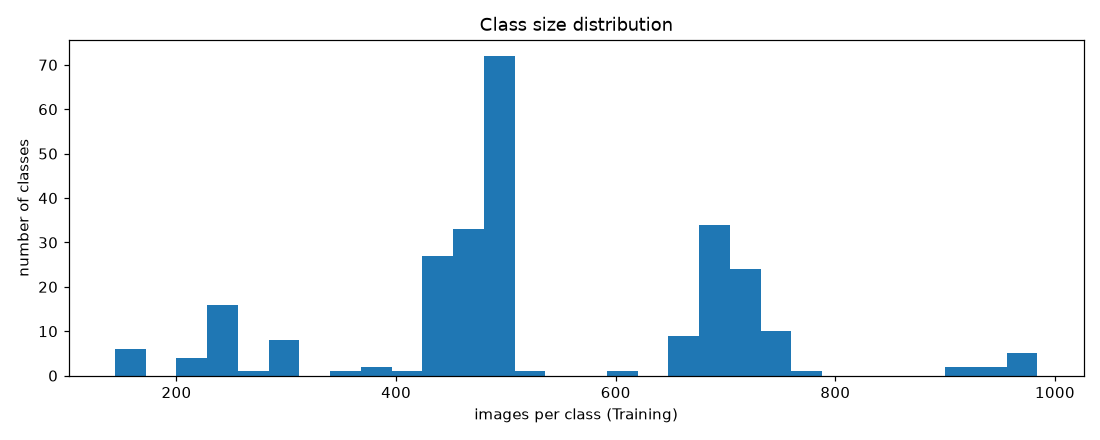

In [2]:
plt.figure(figsize=(10, 4))
plt.hist(list(train_counts.values()), bins=30)
plt.xlabel("images per class (Training)"); plt.ylabel("number of classes")
plt.title("Class size distribution"); plt.show()

Sample images across 32 random classes — clean, cropped, white background:

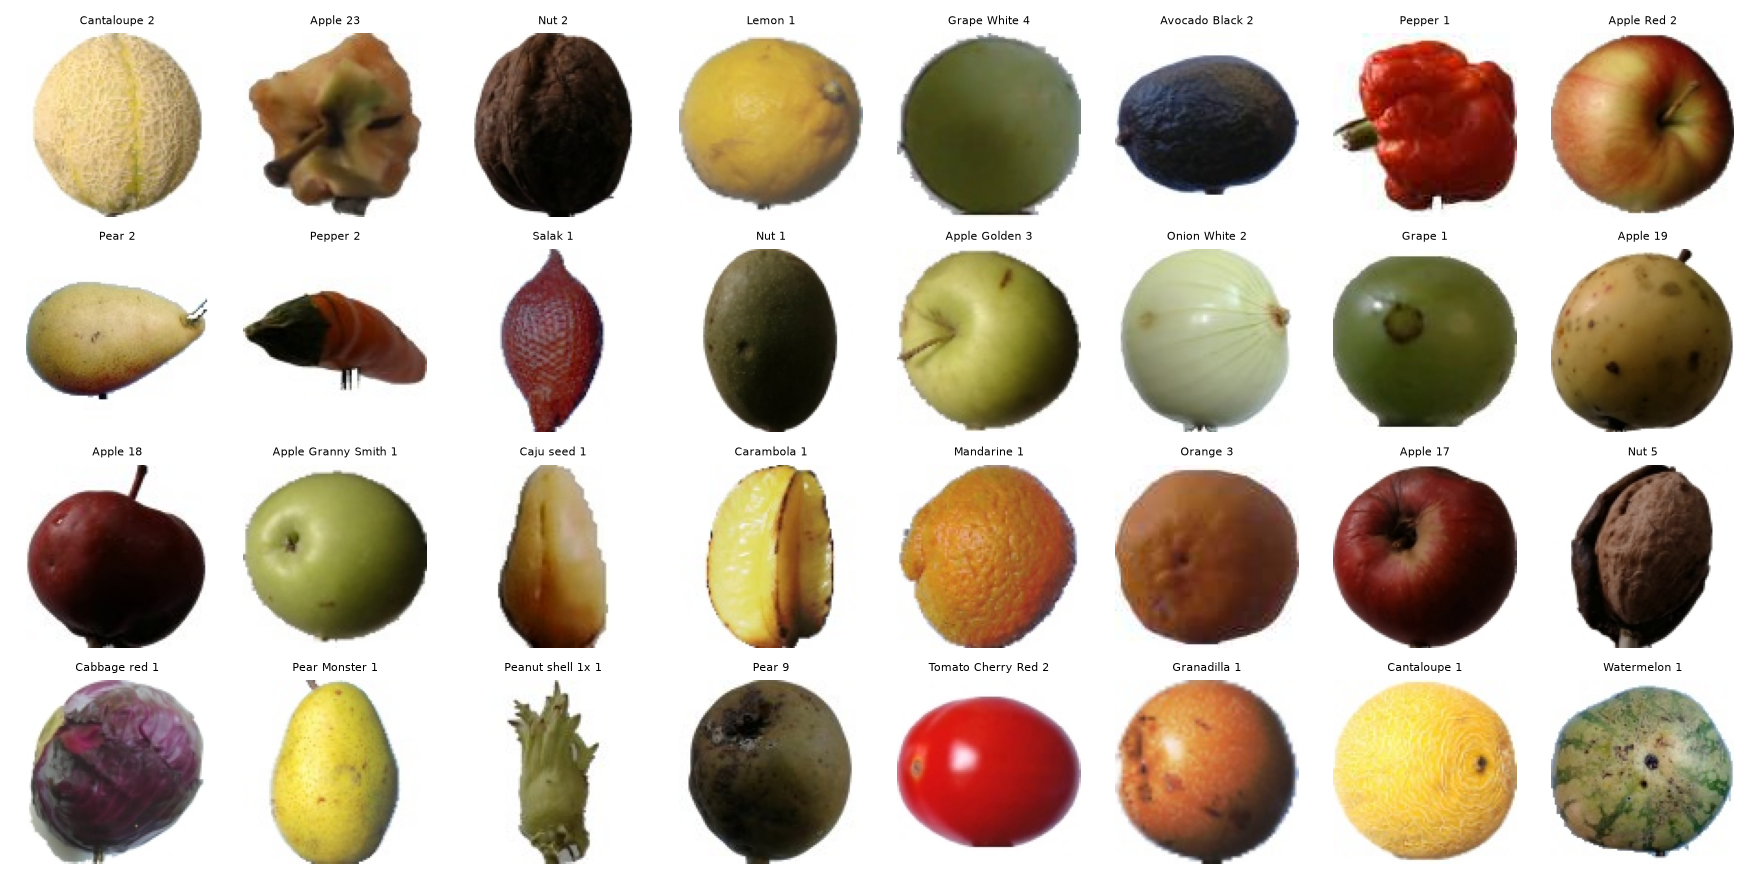

In [3]:
sample_classes = random.sample(class_names, 32)
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for ax, cname in zip(axes.ravel(), sample_classes):
    fdir = f"{DATA_DIR}/Training/{cname}"
    img = keras.utils.load_img(os.path.join(fdir, os.listdir(fdir)[0]))
    ax.imshow(img); ax.set_title(cname, fontsize=7); ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Data pipeline

Deterministic 90/10 train/validation split carved from `Training/` (seeded), plus the dataset's own `Test/` split held out entirely for final evaluation. Augmentation (flip/rotation/zoom) is applied to the training split only. No hardcoded absolute paths — everything is relative to `DATA_DIR`.

In [4]:
raw_train_ds = keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/Training", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    seed=SEED, validation_split=0.1, subset="training", label_mode="int",
)
raw_val_ds = keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/Training", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    seed=SEED, validation_split=0.1, subset="validation", label_mode="int",
)
raw_test_ds = keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/Test", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False, label_mode="int",
)
class_names = raw_train_ds.class_names
num_classes = len(class_names)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
], name="augmentation")

normalize = layers.Rescaling(1.0 / 255)

def prep(ds, training):
    ds = ds.map(lambda x, y: (normalize(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.cache().shuffle(2000, seed=SEED).prefetch(tf.data.AUTOTUNE)
    else:
        ds = ds.cache().prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = prep(raw_train_ds, training=True)
val_ds = prep(raw_val_ds, training=False)
test_ds = prep(raw_test_ds, training=False)

print(f"classes: {num_classes}")
print(f"train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"val batches:   {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"test batches:  {tf.data.experimental.cardinality(test_ds).numpy()}")


Found 137221 files belonging to 260 classes.
Using 123499 files for training.
Found 137221 files belonging to 260 classes.
Using 13722 files for validation.
Found 45724 files belonging to 260 classes.
classes: 260
train batches: 483
val batches:   54
test batches:  179
